In [1]:
import pandas as pd
import numpy as np

# 데이터 불러오기
customers = pd.read_csv("data/customer_hm.csv")
transactions = pd.read_csv("data/transactions_hm.csv")
articles = pd.read_csv("data/articles_hm.csv")

In [3]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   customer_id             1048575 non-null  str  
 1   FN                      1048575 non-null  int64
 2   Active                  1048575 non-null  int64
 3   club_member_status      1048575 non-null  str  
 4   fashion_news_frequency  1048574 non-null  str  
 5   age                     1048575 non-null  int64
dtypes: int64(3), str(3)
memory usage: 48.0 MB


In [4]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   t_dat             1048575 non-null  str    
 1   customer_id       1048575 non-null  str    
 2   article_id        1048575 non-null  int64  
 3   price             1048575 non-null  float64
 4   sales_channel_id  1048575 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 40.0 MB


In [21]:
transactions.describe()

,article_id,price,sales_channel_id
count,1.048575e+06,1.048575e+06,1.048575e+06
mean,6.746672e+08,2.777915e-02,1.695412e+00
std,1.173503e+08,1.935764e-02,4.602328e-01
min,1.087750e+08,2.372880e-04,1.000000e+00
25%,6.289790e+08,1.523729e-02,1.000000e+00
50%,7.059880e+08,2.540678e-02,2.000000e+00
75%,7.500700e+08,3.388136e-02,2.000000e+00
max,8.797400e+08,5.067797e-01,2.000000e+00


In [5]:
articles.info()

<class 'pandas.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   article_id                    105542 non-null  int64
 1   product_code                  105542 non-null  int64
 2   prod_name                     105542 non-null  str  
 3   product_type_no               105542 non-null  int64
 4   product_type_name             105542 non-null  str  
 5   product_group_name            105542 non-null  str  
 6   graphical_appearance_no       105542 non-null  int64
 7   graphical_appearance_name     105542 non-null  str  
 8   colour_group_code             105542 non-null  int64
 9   colour_group_name             105542 non-null  str  
 10  perceived_colour_value_id     105542 non-null  int64
 11  perceived_colour_value_name   105542 non-null  str  
 12  perceived_colour_master_id    105542 non-null  int64
 13  perceived_colour_master_n

In [2]:
# customers 카피본 생성 -> fashion news frequency 버림
customers_copy1 = customers.drop(columns = ["fashion_news_frequency"])
customers_copy1

,customer_id,FN,Active,club_member_status,age
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,49
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,25
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,24
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,54
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,52
...,...,...,...,...,...
1048570,c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d5...,1,1,ACTIVE,22
1048571,c88f5d0deba322a686e7928da6a7f3d2318e102d1c2cdb...,1,1,ACTIVE,41
1048572,c88f99a55b10f6dd50dd87c3ca05af4a8a6c98f3e6fbc5...,0,0,ACTIVE,38
1048573,c88fa15c06519c4bdcab386fea313b226113584b729874...,1,1,ACTIVE,54


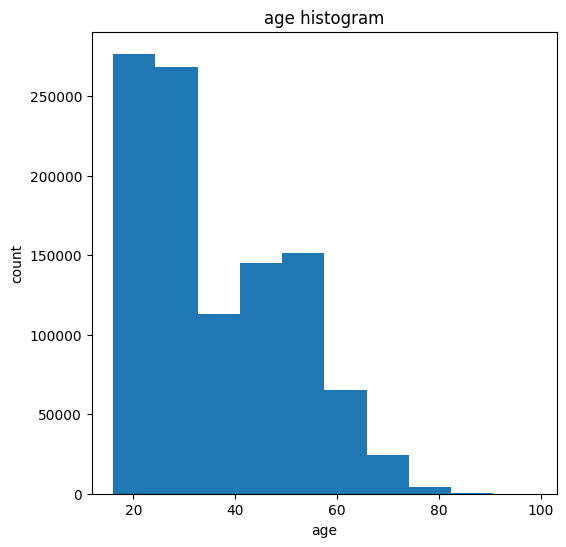

In [3]:
# age의 나이대 파생컬럼을 만들기 전 이상치 확인용 히스토그램
import matplotlib.pyplot as plt
customers_copy2 = customers_copy1.copy()

plt.figure(figsize = (6, 6))
plt.hist(customers_copy2["age"], bins = 10)
plt.xlabel("age")
plt.ylabel("count")
plt.title("age histogram")
plt.show()

In [4]:
# age의 나이대 파생컬럼 "age_group" 생성
customers_copy2["age_group"] = "10대"
customers_copy2.loc[customers_copy2["age"] < 100, "age_group"] = "70대+"
customers_copy2.loc[customers_copy2["age"] <= 69, "age_group"] = "60대"
customers_copy2.loc[customers_copy2["age"] <= 59, "age_group"] = "50대"
customers_copy2.loc[customers_copy2["age"] <= 49, "age_group"] = "40대"
customers_copy2.loc[customers_copy2["age"] <= 39, "age_group"] = "30대"
customers_copy2.loc[customers_copy2["age"] <= 29, "age_group"] = "20대"

customers_copy2["age_group"].value_counts()

age_group
20대     464452
30대     181112
50대     174715
40대     157445
60대      56124
70대+     14727
Name: count, dtype: int64

In [5]:
# transactions 전처리를 위한 카피본 생성
transactions_copy1 = transactions.copy()

In [6]:
# t_dat 컬럼 전처리 전 형식 일치 확인
transactions_copy1[transactions_copy1["t_dat"].str.contains("-") == False]

,t_dat,customer_id,article_id,price,sales_channel_id


In [7]:
# t_dat의 데이터형 문자열 -> 날짜데이터 변환
transactions_copy1["t_dat"] = pd.to_datetime(transactions_copy1["t_dat"])
transactions_copy1["t_dat"]

0         2019-11-05
1         2019-05-22
2         2019-05-10
3         2019-08-26
4         2019-08-10
             ...    
1048570   2019-03-25
1048571   2019-10-18
1048572   2019-04-06
1048573   2019-03-20
1048574   2019-01-13
Name: t_dat, Length: 1048575, dtype: datetime64[us]

In [8]:
# t_dat의 데이터 '연-월' 형식 변환
transactions_copy1["t_dat"] = transactions_copy1["t_dat"].dt.to_period("M")

In [9]:
# 전처리 결과 확인
transactions_copy1["t_dat"].value_counts()

t_dat
2019-06    122043
2019-07    115505
2019-05     99728
2019-04     94073
2019-03     81858
2019-01     81248
2019-08     80219
2019-09     78545
2019-11     76358
2019-10     73820
2019-02     73730
2019-12     71448
Freq: M, Name: count, dtype: int64

In [10]:
articles_copy = articles.copy()

In [11]:
selected_cols = ['article_id', 'product_group_name', 'perceived_colour_master_name', 'index_name', 'garment_group_name']
articles_test = pd.read_csv('data/articles_hm.csv', usecols=selected_cols)

garment_mode = articles_test[articles_test['garment_group_name'] != 'Unknown']['garment_group_name'].mode()[0]
articles_test['garment_group_name'] = articles_test['garment_group_name'].replace('Unknown', garment_mode)

In [42]:
tr_cus = pd.merge(transactions_copy1, customers_copy2, on = "customer_id", how = "left")
tr_cus.isna().sum()

t_dat                      0
customer_id                0
article_id                 0
price                      0
sales_channel_id           0
FN                    235644
Active                235644
club_member_status    235644
age                   235644
age_group             235644
dtype: int64

In [43]:
tr_cus_ar = pd.merge(tr_cus, articles_test, on = "article_id", how = "left")
tr_cus_ar.isna().sum()

t_dat                                0
customer_id                          0
article_id                           0
price                                0
sales_channel_id                     0
FN                              235644
Active                          235644
club_member_status              235644
age                             235644
age_group                       235644
product_group_name                   0
perceived_colour_master_name         0
index_name                           0
garment_group_name                   0
dtype: int64

In [44]:
# 월별 상품군별 매출 groupby -> 제품군별 날짜에 따른 매출 pivot table 제작

mo_pro_pa = tr_cus_ar.groupby(["t_dat", "product_group_name"])["price"].sum()
mo_pro_pa = mo_pro_pa.to_frame()
pv_mpp = pd.pivot_table(mo_pro_pa,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_mpp

t_dat,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
product_group_name,,,,,,,,,,,,
Accessories,66.513559,62.809288,62.980576,65.280390,68.408339,65.018576,67.019729,57.870831,69.094898,72.611932,86.277966,80.355966
Bags,0.133864,0.084695,0.313441,0.060983,0.203322,0.295441,0.589203,1.458864,1.435407,0.827017,1.249831,0.826627
Cosmetic,0.031576,0.024492,0.008458,NaN,NaN,0.013017,0.019458,0.005898,0.016458,0.021712,NaN,NaN
Furniture,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007322,0.039915,0.118729,0.037254
Garment Full body,182.372695,209.080779,330.312813,524.765694,529.226983,648.162016,491.154254,287.544067,276.918169,259.187406,325.182457,279.086135
Garment Lower body,559.040745,563.925898,662.899118,743.382525,734.072134,825.248643,684.504677,556.516525,676.825610,578.168982,530.548339,461.605372
Garment Upper body,932.763574,823.499508,899.996473,839.574914,797.443015,799.213641,703.157287,710.808677,1274.635745,1203.619100,1237.101559,882.139117
Garment and Shoe care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028508,NaN,0.016932
Interior textile,0.008119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


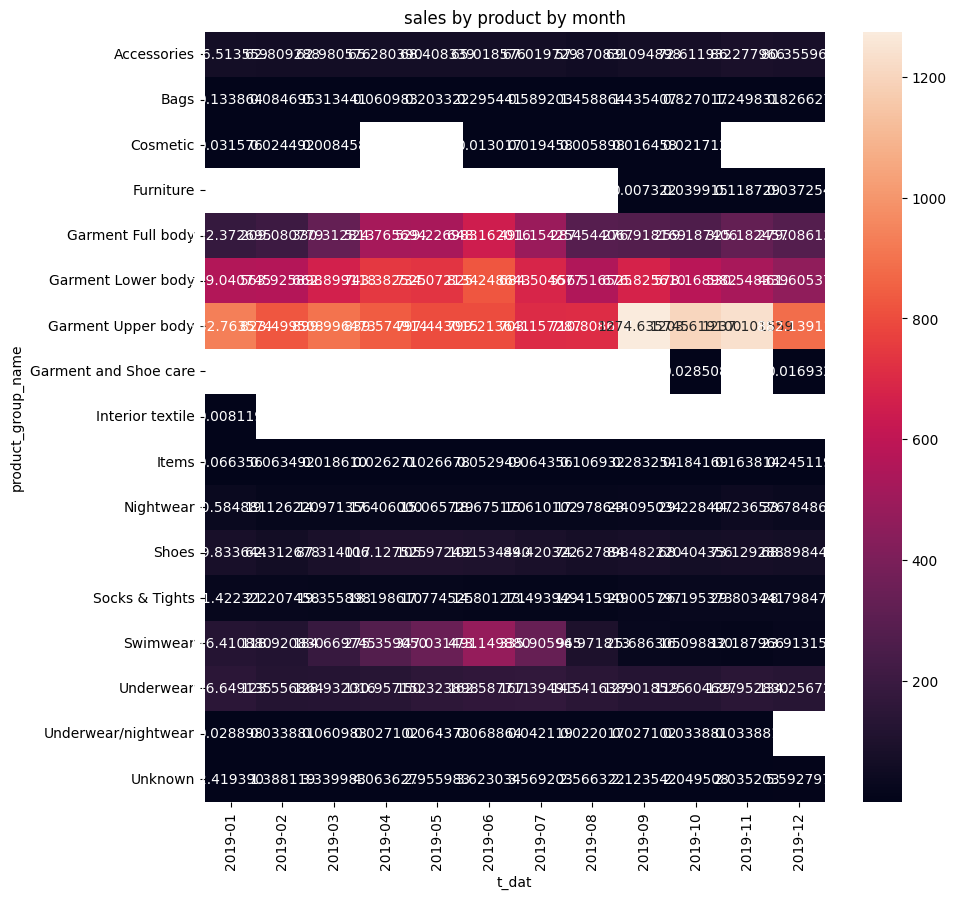

In [15]:
# 1차 히트맵 제작
# 결측치, price의 소숫점 문제로 보기 좋진 않음
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 10))
sale_heat = sns.heatmap(pv_mpp, annot = True, fmt = "f")
plt.title("sales by product by month")
plt.show()

In [ ]:
# 2차 히트맵 제작을 위한 mo_pro_pa의 복사본 제작
# 그 과정에서 인덱스가 되었던 product_group_name을 컬럼으로 다시 밀어냄
mpp_copy = mo_pro_pa.copy()
mpp_copy = mpp_copy.reset_index(drop = False)
mpp_copy = mpp_copy.set_index("t_dat")
mpp_copy

,product_group_name,price
t_dat,,
2019-01,Accessories,66.513559
2019-01,Bags,0.133864
2019-01,Cosmetic,0.031576
2019-01,Garment Full body,182.372695
2019-01,Garment Lower body,559.040745
...,...,...
2019-12,Shoes,68.898441
2019-12,Socks & Tights,28.798475
2019-12,Swimwear,23.913152


In [17]:
# 값이 다른 제품군과 비교해 너무 작은 것들을 '기타' 로 매핑
product_map = ["Unknown", "Bags", "Items", "Cosmetic", "Furniture", "Underwear/nightwear", "Garment and Shoe care", "Interior textile"]
mpp_copy.loc[mpp_copy["product_group_name"].isin(product_map), "product_group_name"] = "Others"

In [18]:
# 제품군별 월별 매출총합 피벗 테이블 제작
pv_mpp_copy = pd.pivot_table(mpp_copy,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_mpp_copy

t_dat,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
product_group_name,,,,,,,,,,,,
Accessories,66.513559,62.809288,62.980576,65.280390,68.408339,65.018576,67.019729,57.870831,69.094898,72.611932,86.277966,80.355966
Garment Full body,182.372695,209.080779,330.312813,524.765694,529.226983,648.162016,491.154254,287.544067,276.918169,259.187406,325.182457,279.086135
Garment Lower body,559.040745,563.925898,662.899118,743.382525,734.072134,825.248643,684.504677,556.516525,676.825610,578.168982,530.548339,461.605372
Garment Upper body,932.763574,823.499508,899.996473,839.574914,797.443015,799.213641,703.157287,710.808677,1274.635745,1203.619100,1237.101559,882.139117
Nightwear,30.584881,19.126220,14.971356,17.406000,15.065729,18.675170,15.610102,17.978644,23.095034,29.228407,44.236576,33.784864
Others,2.688203,1.594678,3.741475,4.177983,3.250356,4.053305,4.284339,4.160034,3.893085,3.184712,3.601458,6.718729
Shoes,79.833644,62.312678,87.314017,106.127525,105.972491,102.534440,89.420322,74.627898,84.482220,68.404356,73.129288,68.898441
Socks & Tights,21.422322,21.207458,19.355898,18.198610,17.774525,14.801271,13.493949,12.415949,20.005797,26.195373,29.803441,28.798475
Swimwear,126.410880,118.920830,184.669745,275.359050,347.031491,473.149880,335.905965,94.971813,25.686305,16.098830,12.187966,23.913152


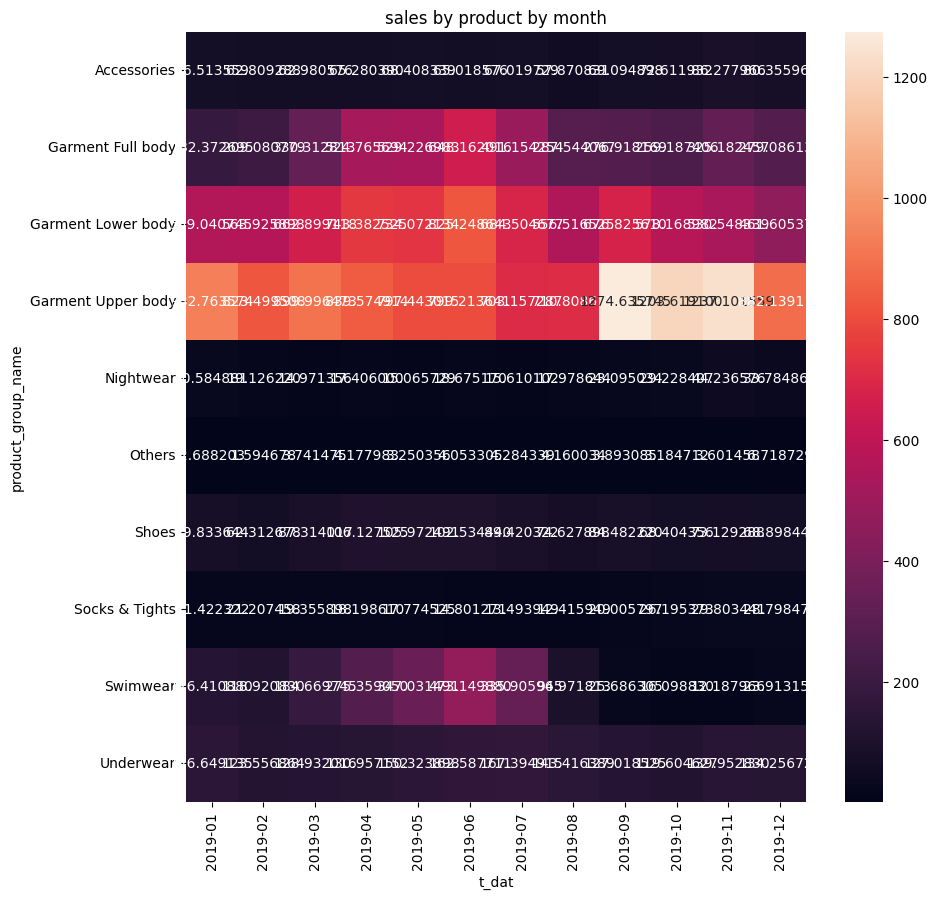

In [19]:
# 2차 히트맵 제작
# 자잘한 것들이 '기타' 로 묶이면서 결측치도 해결되고 이전보단 깔끔해짐
# 하지만 여전히 price의 소수값 이슈로 보기 힘듬
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 10))
sale_heat = sns.heatmap(pv_mpp_copy, annot = True, fmt = "f")
plt.title("sales by product by month")
plt.show()

In [20]:
# 3차 히트맵 제작을 위한 기존 복사본을 다시 복사
mpp_copy2 = mpp_copy.copy()
mpp_copy2

,product_group_name,price
t_dat,,
2019-01,Accessories,66.513559
2019-01,Others,0.133864
2019-01,Others,0.031576
2019-01,Garment Full body,182.372695
2019-01,Garment Lower body,559.040745
...,...,...
2019-12,Shoes,68.898441
2019-12,Socks & Tights,28.798475
2019-12,Swimwear,23.913152


In [21]:
# price의 소수 이슈를 해결하기 위해 매출총합 값을 정수로 변환해 소숫점 이하 값 버림
mpp_copy2["price"] = mpp_copy2["price"].astype(int)

In [22]:
# price 정돈이 끝난 복사본도 이전처럼 피벗 테이블 제작
pv_mpp_copy2 = pd.pivot_table(mpp_copy2,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_mpp_copy2

t_dat,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
product_group_name,,,,,,,,,,,,
Accessories,66,62,62,65,68,65,67,57,69,72,86,80
Garment Full body,182,209,330,524,529,648,491,287,276,259,325,279
Garment Lower body,559,563,662,743,734,825,684,556,676,578,530,461
Garment Upper body,932,823,899,839,797,799,703,710,1274,1203,1237,882
Nightwear,30,19,14,17,15,18,15,17,23,29,44,33
Others,2,1,3,4,2,3,3,3,3,2,3,5
Shoes,79,62,87,106,105,102,89,74,84,68,73,68
Socks & Tights,21,21,19,18,17,14,13,12,20,26,29,28
Swimwear,126,118,184,275,347,473,335,94,25,16,12,23


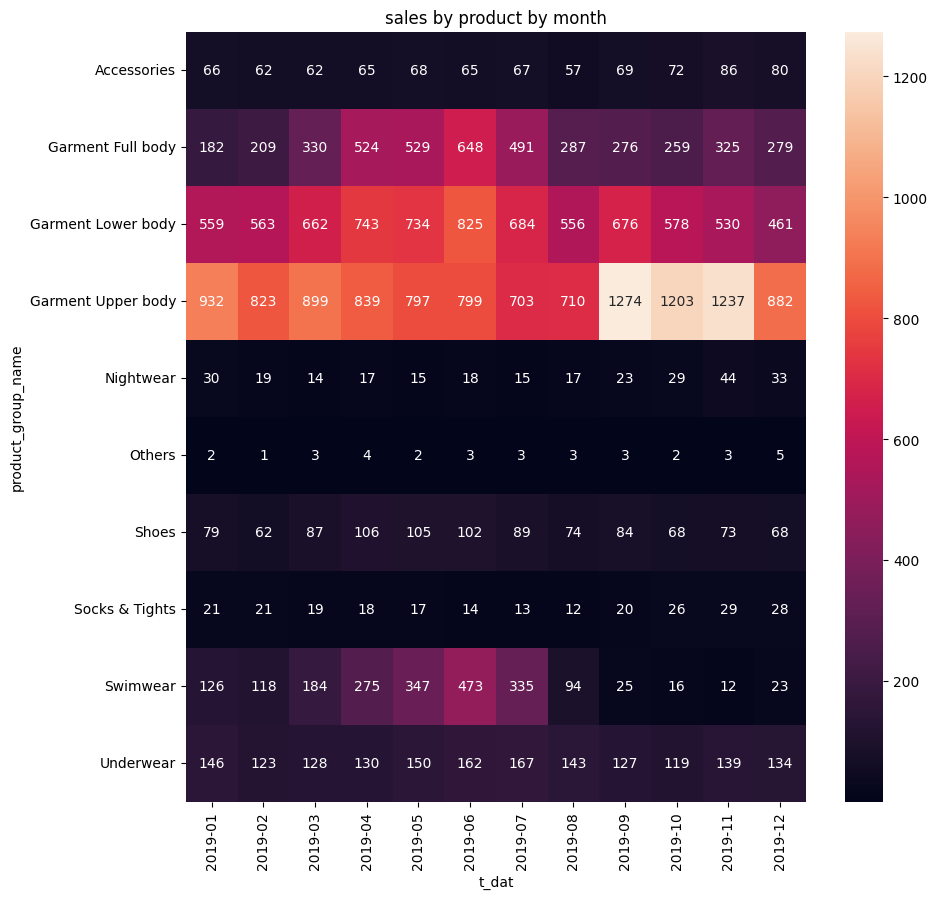

In [23]:
# 최종 3차 히트맵 제작
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 10))
sale_heat = sns.heatmap(pv_mpp_copy2, annot = True, fmt = "d")
plt.title("sales by product by month")
plt.show()

In [34]:
# 수치가 큰 전신, 상의 하의 옷 때문에 다른 제품군의 차이가 보이지 않는 문제로 두 그룹을 분리
mpp_copy3 = mpp_copy2.copy()
group_map =["Garment Full body", "Garment Lower body", "Garment Upper body"] 
mpp_garment = mpp_copy3[mpp_copy3["product_group_name"].isin(group_map)]
mpp_others = mpp_copy3[~mpp_copy3["product_group_name"].isin(group_map)]
mpp_others

,product_group_name,price
t_dat,,
2019-01,Accessories,66
2019-01,Others,0
2019-01,Others,0
2019-01,Others,0
2019-01,Others,0
...,...,...
2019-12,Shoes,68
2019-12,Socks & Tights,28
2019-12,Swimwear,23


In [ ]:
# 두 개로 나눈 그룹을 각각 pivot table로
pv_garment = pd.pivot_table(mpp_garment,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")
pv_others = pd.pivot_table(mpp_others,
                        index = "product_group_name",
                        columns = "t_dat",
                        values = "price",
                        aggfunc = "sum")

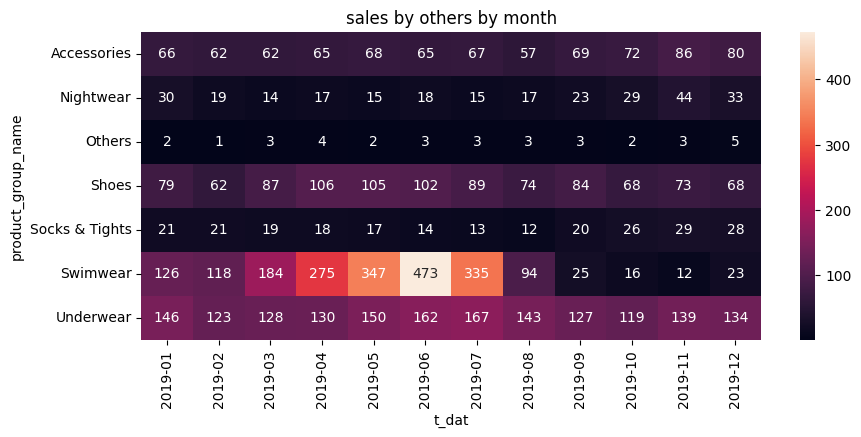

In [ ]:
# 수치가 작았던 그룹의 히트맵
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 4))
sale_heat = sns.heatmap(pv_others, annot = True, fmt = "d")
plt.title("sales by others by month")
plt.show()

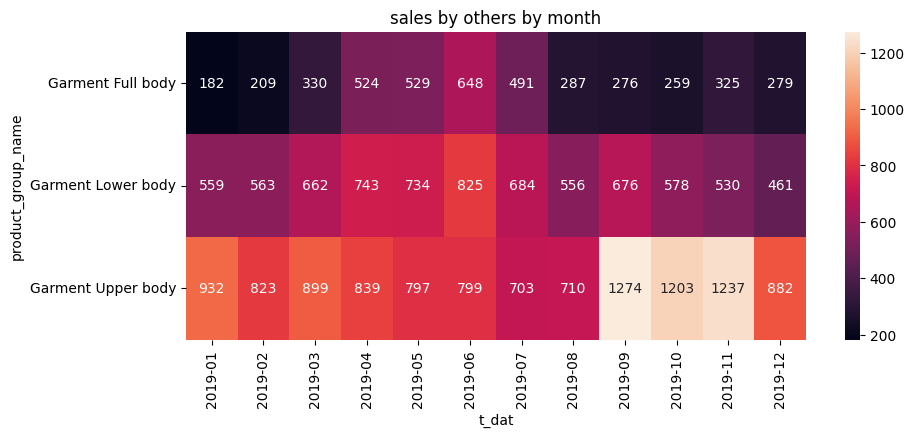

In [ ]:
# 수치가 컸던 그룹의 히트맵
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 4))
sale_heat = sns.heatmap(pv_garment, annot = True, fmt = "d")
plt.title("sales by others by month")
plt.show()

In [46]:
# 나이대별 제품군별 매출
# 나이대별 제품군별 groupby로 매출 총합 -> 제품군의 '기타' 매핑 -> 피벗 테이블 제작
age_pro_sa = tr_cus_ar.groupby(["age_group", "product_group_name"])["price"].sum().reset_index(drop = False)
age_pro_sa["price"] = age_pro_sa["price"].astype(int)

product_map = ["Unknown", "Bags", "Items", "Cosmetic", "Furniture", "Underwear/nightwear", "Garment and Shoe care", "Interior textile"]
age_pro_sa.loc[age_pro_sa["product_group_name"].isin(product_map), "product_group_name"] = "Others"

pv_aps = pd.pivot_table(age_pro_sa,
                        index = "product_group_name",
                        columns = "age_group",
                        values = "price",
                        aggfunc = "sum")
pv_aps

age_group,20대,30대,40대,50대,60대,70대+
product_group_name,,,,,,
Accessories,299,132,85,92,24,5
Garment Full body,1345,729,526,597,145,24
Garment Lower body,2346,1191,974,1061,248,46
Garment Upper body,3437,1706,1322,1606,436,92
Nightwear,84,48,36,37,9,1
Others,14,6,4,4,1,0
Shoes,310,195,114,121,34,5
Socks & Tights,73,43,31,31,6,0
Swimwear,802,302,201,235,35,3


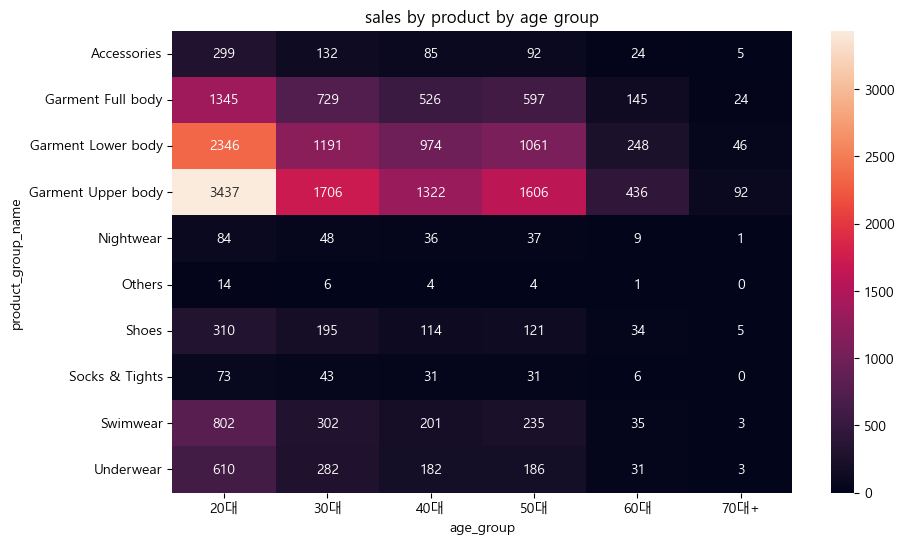

In [47]:
# 나이대별 제품군별 매출 총합 히트맵 제작
# 나이대에 한글이 들어가있어 한글 폰트 불러옴
# 이외엔 월별 제품군별 매출 총합 구할때와 동일
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "굴림", "Gulim"]
installed = {f.name for f in fm.fontManager.ttflist}

for font in candidates:
    if font in installed:
        plt.rcParams["font.family"] = font
        break

plt.figure(figsize = (10, 6))
sale_heat = sns.heatmap(pv_aps, annot = True, fmt = "d")
plt.title("sales by product by age group")
plt.show()

In [48]:
product_qty = tr_cus_ar.groupby("product_group_name")["article_id"].count().reset_index(drop = False)
product_qty.loc[product_qty["product_group_name"].isin(product_map), "product_group_name"] = "Others"
product_qty = product_qty.groupby("product_group_name")["article_id"].sum().reset_index(drop = False)
product_qty

,product_group_name,article_id
0,Accessories,52220
1,Garment Full body,117701
2,Garment Lower body,232472
3,Garment Upper body,415881
4,Nightwear,11283
5,Others,1888
6,Shoes,25554
7,Socks & Tights,21267
8,Swimwear,89657
9,Underwear,80652


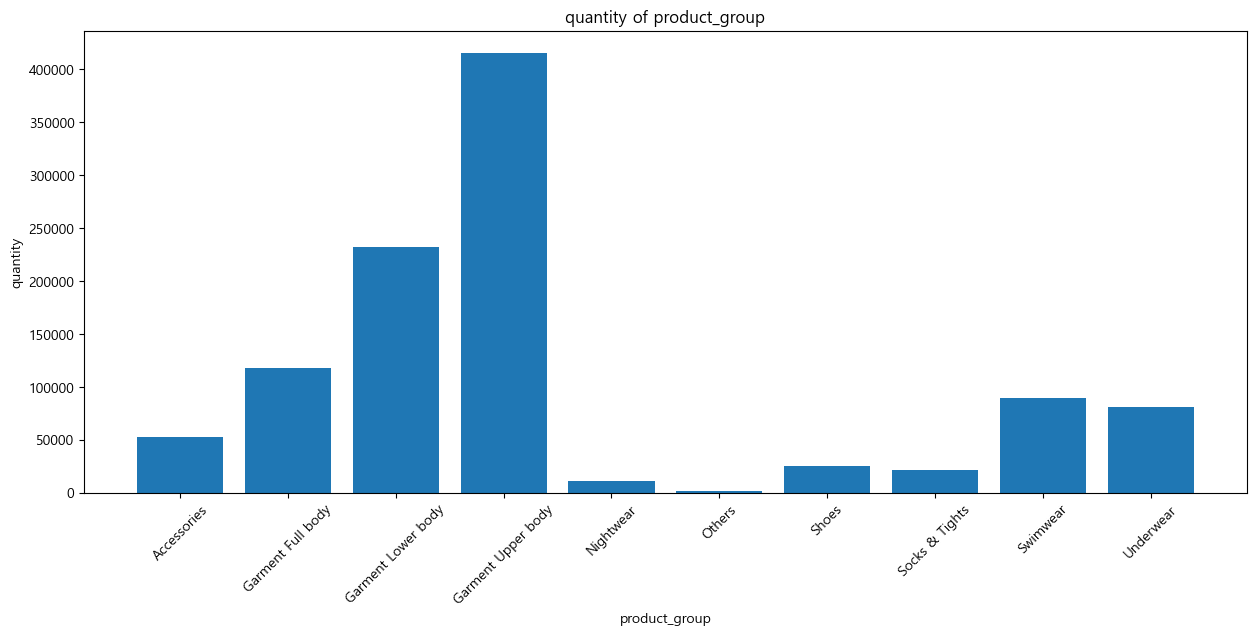

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15, 6))
plt.bar(product_qty["product_group_name"], product_qty["article_id"])
plt.xlabel("product_group")
plt.ylabel("quantity")
plt.xticks(rotation = 45)
plt.title("quantity of product_group")
plt.show()

In [50]:
season_map = {
    1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Fall', 10:'Fall', 11:'Fall',
    12:'Winter'}

tr_cus_ar['season'] = tr_cus_ar['t_dat'].dt.month.map(season_map)
tr_cus_ar['season']

0            Fall
1          Spring
2          Spring
3          Summer
4          Summer
            ...  
1048570    Spring
1048571      Fall
1048572    Spring
1048573    Spring
1048574    Winter
Name: season, Length: 1048575, dtype: str

In [51]:
product_sale = tr_cus_ar.groupby("product_group_name")["price"].sum().reset_index(drop = False)
product_sale["price"] = product_sale["price"].astype(int)
product_sale.loc[product_sale["product_group_name"].isin(product_map), "product_group_name"] = "Others"
product_sale = product_sale.groupby("product_group_name")["price"].sum().reset_index(drop = False)
product_sale

,product_group_name,price
0,Accessories,824
1,Garment Full body,4342
2,Garment Lower body,7576
3,Garment Upper body,11103
4,Nightwear,279
5,Others,43
6,Shoes,1003
7,Socks & Tights,243
8,Swimwear,2034
9,Underwear,1674


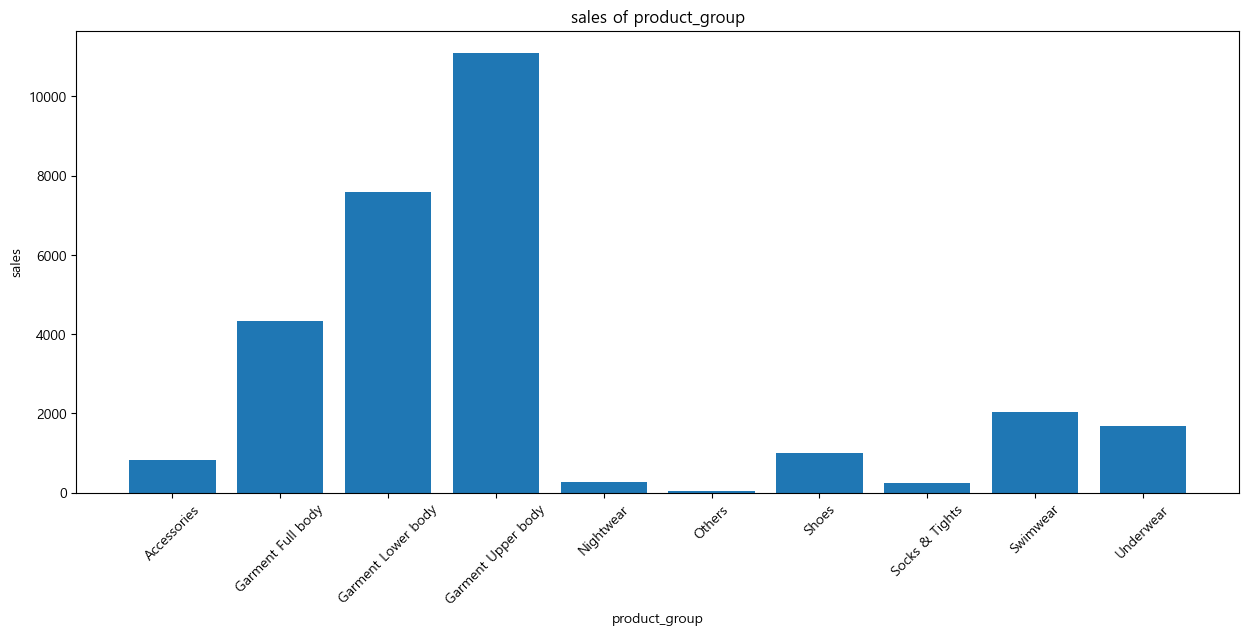

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15, 6))
plt.bar(product_sale["product_group_name"], product_sale["price"])
plt.xlabel("product_group")
plt.ylabel("sales")
plt.xticks(rotation = 45)
plt.title("sales of product_group")
plt.show()